## **Notebook PC#05**
## Comparing the performance of distinct activation functions when a CNN classifier is applied to the MNIST database.
**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** Daniele Souza Gonçalves **RA:** 248029 <br>
**Aluno(a):** Joao Lucas Morais Ortiz **RA:** 297611 <br>

# The activation functions being compared are:
*   Hyperbolic Tangent Function
*   ReLU Function
*   Leaky-ReLU Function
*   Swish Function

Please refer to [this material](https://medium.com/data-science/comparison-of-activation-functions-for-deep-neural-networks-706ac4284c8a) for a discussion, and to [this material](https://colab.research.google.com/drive/1JGRVpj0-0uaDrUqBpjIw9LT9us48DC89) and [this material](https://colab.research.google.com/drive/1fCVQ8JFiuyVWs6BoCIw0UqWPZPshU25h) for the original code, which was properly adapted here.

## Plotting those activation functions, including the sigmoid function.

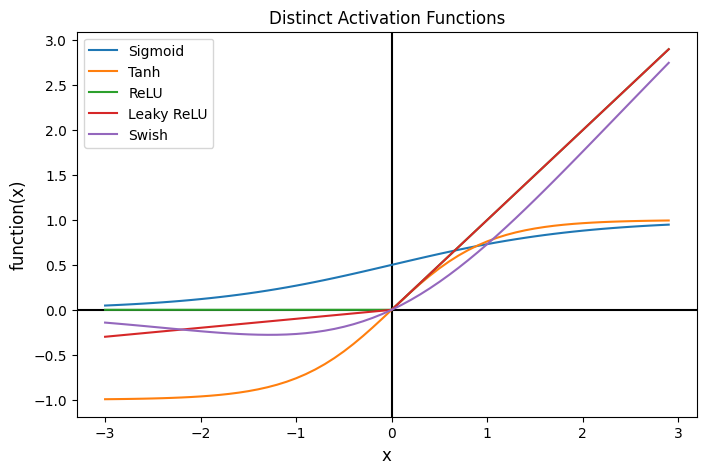

In [1]:
# Importing the required libraries
import math
import matplotlib.pyplot as plt
import numpy as np

# Use the crude definition of the activation functions
# Sigmoid Function
def sigmoid(x):
    a = []
    for i in x:
        a.append(1/(1+math.exp(-i)))
    return a
# Hyperbolic Tanjant Function
def tanh(x, derivative=False):
    if (derivative == True):
        return (1 - (x ** 2))
    return np.tanh(x)
# ReLU Function
def re(x):
    b = []
    for i in x:
        if i<0:
            b.append(0)
        else:
            b.append(i)
    return b
# Leaky ReLU Function
def lr(x):
    b = []
    for i in x:
        if i<0:
            b.append(i/10)
        else:
            b.append(i)
    return b

# Determining the intervals to be created for the graph
x = np.arange(-3., 3., 0.1)
sig = sigmoid(x)
tanh = tanh(x)
relu = re(x)
leaky_relu = lr(x)
swish = sig*x

# Displaying the functions
plt.figure(figsize=(8, 5))
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
line_1, = plt.plot(x,sig, label='Sigmoid')
line_2, = plt.plot(x,tanh, label='Tanh')
line_3, = plt.plot(x,relu, label='ReLU')
line_4, = plt.plot(x,leaky_relu, label='Leaky ReLU')
line_5, = plt.plot(x,swish, label='Swish')
plt.legend(handles=[line_1, line_2, line_3, line_4, line_5])
plt.xlabel('x', fontsize=12)
plt.ylabel('function(x)', fontsize=12)
plt.title('Distinct Activation Functions', fontsize=12)
plt.show()

In [2]:
from __future__ import print_function
import keras
from keras.datasets import mnist
from keras.models import load_model
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras. layers import Conv2D, MaxPooling2D
from keras import backend as K

import tensorflow  as tf
from keras.layers import *
from keras.callbacks import ReduceLROnPlateau

import matplotlib.pyplot as plt

## Downloading the Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

### Configuration Settings

In [4]:
batch_size = 128 # Batch-Size
num_classes = 10 # Number of Class
epochs = 20 # Number of epoch

In [5]:
img_rows, img_cols = 28, 28

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors into binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


### Hyperbolic Tangent Function

In [6]:
model = Sequential()
model.add(keras.Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3)))
model.add(Activation('tanh'))
model.add(Conv2D(64, (3, 3)))
model.add(Activation('tanh'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128))
model.add(Activation('tanh'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])
model.summary()

2026-04-25 23:16:52.766670: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-25 23:16:52.766697: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-25 23:16:52.766703: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-25 23:16:52.767033: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-25 23:16:52.767339: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 activation (Activation)     (None, 26, 26, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 activation_1 (Activation)   (None, 24, 24, 64)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                        

### Training and Validation

In [7]:
hist_tanh=model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20


2026-04-25 23:16:53.722229: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-25 23:16:53.762651: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


469/469 [==============================] - 12s 23ms/step - loss: 0.2306 - accuracy: 0.9303 - val_loss: 0.0785 - val_accuracy: 0.9757
Epoch 2/20
469/469 [==============================] - 11s 23ms/step - loss: 0.0979 - accuracy: 0.9712 - val_loss: 0.0633 - val_accuracy: 0.9793
Epoch 3/20
469/469 [==============================] - 10s 22ms/step - loss: 0.0763 - accuracy: 0.9767 - val_loss: 0.0507 - val_accuracy: 0.9838
Epoch 4/20
469/469 [==============================] - 11s 22ms/step - loss: 0.0642 - accuracy: 0.9803 - val_loss: 0.0545 - val_accuracy: 0.9838
Epoch 5/20
469/469 [==============================] - 10s 22ms/step - loss: 0.0587 - accuracy: 0.9818 - val_loss: 0.0526 - val_accuracy: 0.9841
Epoch 6/20
469/469 [==============================] - 10s 22ms/step - loss: 0.0561 - accuracy: 0.9822 - val_loss: 0.0519 - val_accuracy: 0.9832
Epoch 7/20
469/469 [==============================] - 11s 23ms/step - loss: 0.0512 - accuracy: 0.9836 - val_loss: 0.0471 - val_accuracy: 0.9848
Epo

### ReLU Function

In [8]:
model = Sequential()
model.add(keras.Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 activation_3 (Activation)   (None, 26, 26, 32)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 activation_4 (Activation)   (None, 24, 24, 64)        0         
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 12, 12, 64)        0         
                                                      

### Training and Validation

In [9]:
hist_relu=model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20


2026-04-25 23:20:33.179193: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


469/469 [==============================] - 11s 22ms/step - loss: 0.3211 - accuracy: 0.9097 - val_loss: 0.0787 - val_accuracy: 0.9784
Epoch 2/20
469/469 [==============================] - 10s 22ms/step - loss: 0.1943 - accuracy: 0.9594 - val_loss: 0.1010 - val_accuracy: 0.9812
Epoch 3/20
469/469 [==============================] - 10s 22ms/step - loss: 0.2878 - accuracy: 0.9600 - val_loss: 0.1722 - val_accuracy: 0.9820
Epoch 4/20
469/469 [==============================] - 13s 28ms/step - loss: 0.4302 - accuracy: 0.9614 - val_loss: 0.2076 - val_accuracy: 0.9825
Epoch 5/20
469/469 [==============================] - 12s 25ms/step - loss: 0.6037 - accuracy: 0.9630 - val_loss: 0.2326 - val_accuracy: 0.9851
Epoch 6/20
469/469 [==============================] - 11s 23ms/step - loss: 0.7853 - accuracy: 0.9639 - val_loss: 0.4643 - val_accuracy: 0.9829
Epoch 7/20
469/469 [==============================] - 11s 24ms/step - loss: 1.0418 - accuracy: 0.9652 - val_loss: 0.4052 - val_accuracy: 0.9861
Epo

### Leaky-ReLU Function

In [10]:
model = Sequential()
model.add(keras.Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3)))
model.add(LeakyReLU(alpha=.001))
model.add(Conv2D(64, (3, 3)))
model.add(LeakyReLU(alpha=.001))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128))
model.add(LeakyReLU(alpha=.001))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 26, 26, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 24, 24, 64)        0         
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 12, 12, 64)        0         
                                                      

### Training and Validation

In [11]:
hist_LeakyReLU=model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20


2026-04-25 23:24:17.536898: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


469/469 [==============================] - 11s 23ms/step - loss: 0.2369 - accuracy: 0.9281 - val_loss: 0.0505 - val_accuracy: 0.9837
Epoch 2/20
469/469 [==============================] - 10s 22ms/step - loss: 0.0719 - accuracy: 0.9782 - val_loss: 0.0346 - val_accuracy: 0.9884
Epoch 3/20
469/469 [==============================] - 11s 23ms/step - loss: 0.0526 - accuracy: 0.9840 - val_loss: 0.0346 - val_accuracy: 0.9891
Epoch 4/20
469/469 [==============================] - 11s 23ms/step - loss: 0.0416 - accuracy: 0.9873 - val_loss: 0.0285 - val_accuracy: 0.9910
Epoch 5/20
469/469 [==============================] - 11s 24ms/step - loss: 0.0342 - accuracy: 0.9891 - val_loss: 0.0300 - val_accuracy: 0.9903
Epoch 6/20
469/469 [==============================] - 11s 23ms/step - loss: 0.0312 - accuracy: 0.9902 - val_loss: 0.0288 - val_accuracy: 0.9916
Epoch 7/20
469/469 [==============================] - 12s 25ms/step - loss: 0.0270 - accuracy: 0.9916 - val_loss: 0.0246 - val_accuracy: 0.9923
Epo

### Swish Function

In [12]:
model = Sequential()
model.add(keras.Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3)))
model.add(Activation('swish'))
model.add(Conv2D(64, (3, 3)))
model.add(Activation('swish'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128))
model.add(Activation('swish'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 activation_6 (Activation)   (None, 26, 26, 32)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 activation_7 (Activation)   (None, 24, 24, 64)        0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 12, 12, 64)        0         
                                                      

### Training and Validation

In [13]:
hist_swish=model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20


2026-04-25 23:28:13.427672: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


469/469 [==============================] - 20s 41ms/step - loss: 0.2470 - accuracy: 0.9262 - val_loss: 0.0591 - val_accuracy: 0.9818
Epoch 2/20
469/469 [==============================] - 17s 36ms/step - loss: 0.0786 - accuracy: 0.9762 - val_loss: 0.0402 - val_accuracy: 0.9857
Epoch 3/20
469/469 [==============================] - 17s 36ms/step - loss: 0.0561 - accuracy: 0.9826 - val_loss: 0.0373 - val_accuracy: 0.9875
Epoch 4/20
469/469 [==============================] - 17s 37ms/step - loss: 0.0441 - accuracy: 0.9864 - val_loss: 0.0348 - val_accuracy: 0.9878
Epoch 5/20
469/469 [==============================] - 18s 37ms/step - loss: 0.0381 - accuracy: 0.9879 - val_loss: 0.0318 - val_accuracy: 0.9897
Epoch 6/20
469/469 [==============================] - 17s 36ms/step - loss: 0.0346 - accuracy: 0.9891 - val_loss: 0.0355 - val_accuracy: 0.9888
Epoch 7/20
469/469 [==============================] - 17s 37ms/step - loss: 0.0296 - accuracy: 0.9905 - val_loss: 0.0306 - val_accuracy: 0.9899
Epo

In [14]:
hists = [hist_tanh, hist_relu, hist_LeakyReLU, hist_swish]

## COMPARISON OF RESULTS

In [15]:
def plot_history(hists, attribute='val_loss', loc='lower right'):
    ylabel = {'loss': 'loss', 'acc': 'accuracy'}
    title = {'val_loss': 'valid.loss', 'loss': 'trn.loss', 'val_acc': 'valid.accuracy', 'acc': 'trn.accuracy'}
    num_hists = len(hists)

    plt.figure(figsize=(8, 5))
    # plt.axis(axis)
    for i in range(num_hists):
        plt.plot(hists[i].history[attribute])
    plt.title(title.get(attribute, attribute))
    plt.ylabel(ylabel.get(attribute, attribute))
    plt.xlabel('epoch')
    plt.legend(['tanh', 'ReLU', 'Leaky_ReLU', 'Swish'], loc=loc)

    plt.show()

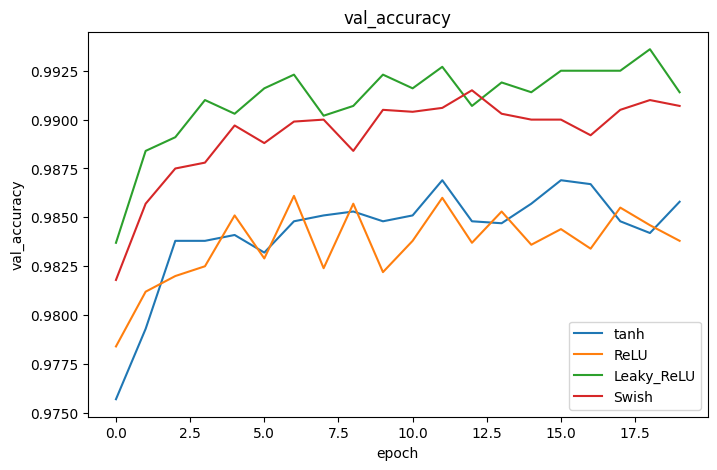

In [16]:
plot_history(hists, attribute='val_accuracy', loc='lower right')

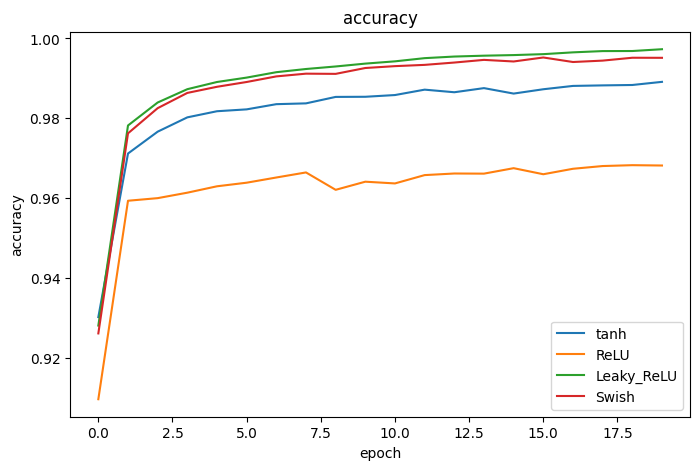

In [17]:
plot_history(hists, attribute='accuracy', loc='lower right')

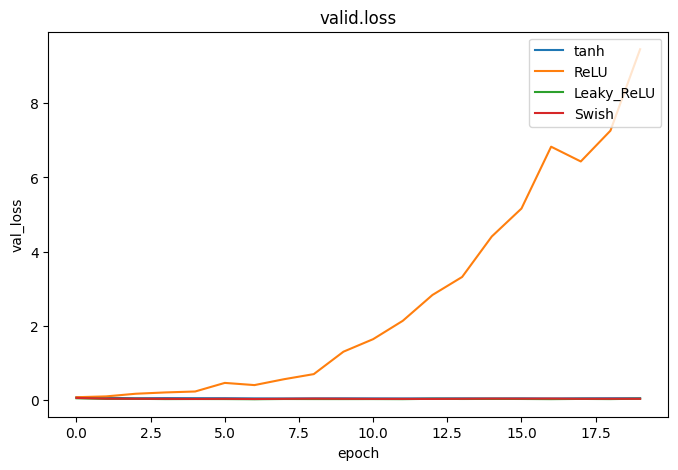

In [18]:
plot_history(hists, attribute='val_loss', loc='upper right')

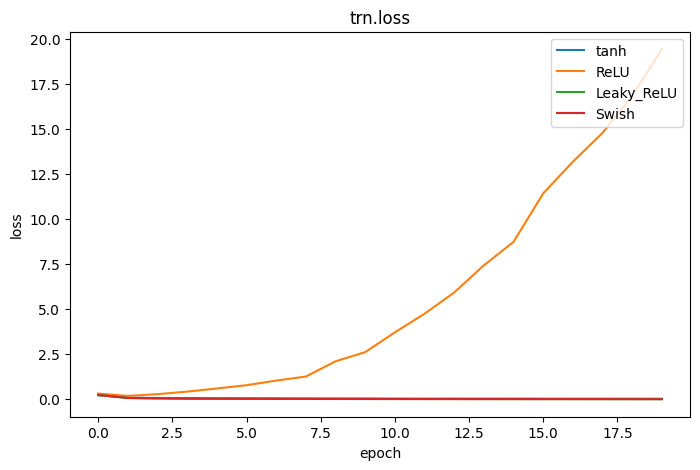

In [19]:
plot_history(hists, attribute='loss', loc='upper right')

<font color="green">
Atividade única <br>
Faça uma análise dos resultados obtidos. A seguir procure discorrer acerca da possibilidade de estender a sua análise a outros casos de estudo e a outras arquiteturas de redes neurais. <br>
</font>

Resposta:

Analisando os resultados obtidos pelas diferentes funções de ativação na base MNIST, podemos notar que todas as funções conseguiram um bom desempenho, todas com acurácia acima de 98%.

A função Leaky-ReLU foi a que se saiu melhor, atingindo cerca de 99.14% de acurácia. Isso pode ser explicado porque a Leaky-ReLU não "zera" completamente os valores negativos como a ReLU normal faz, permitindo que a rede continue aprendendo sem que os neurônios "morram". A função Swish obteve um desempenho quase igual, com 99.07%, e com a menor perda (loss) de todas (0.036). Como ela é uma curva mais suave, ajuda bastante a manter a estabilidade do gradiente. A Tanh também foi bem (98.58%), pois tem a saída centrada em zero, o que ajuda no começo do treinamento. Já a ReLU comum obteve a menor acurácia (98.38%) e apresentou uma perda (loss) bem alta e instável (cerca de 9.45), o que indica que ela deve ter sofrido com o problema dos neurônios mortos ou alguma instabilidade numérica no cálculo do erro.

Pensando em estender essa análise para outros casos de estudo e arquiteturas mais complexas, se fossemos trabalhar com redes neurais muito mais profundas (como ResNets em imagens complexas ou Transformers), a função Tanh perderia muita performance e deixaria de ser viável por causa do problema do desaparecimento do gradiente. Nesses casos mais avançados, o uso de funções não-monotônicas como a Swish ou variantes da Leaky-ReLU se torna quase obrigatório, pois elas preservam muito melhor o fluxo da informação e são o que mais se usa nos modelos atuais. Em contrapartida, se a arquitetura fosse uma rede recorrente (RNN ou LSTM) para dados temporais, a Tanh ainda seria uma excelente escolha, pois ela ajuda a manter os valores do estado interno da rede bem comportados entre -1 e 1.
